<a href="https://colab.research.google.com/github/bayozid/pennylane-/blob/main/Classical_Deploying_Quantum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 58.1 MB/s eta 0:00:00


In [ ]:
!pip install pennylane optax

In [ ]:
# imports
import jax
import jax.numpy as jnp
import optax

# create a jax PRNGKey
key = jax.random.PRNGKey(42)


In [ ]:
# define your number of qubits
n_qubits = 4

# assemble gates and observables
gates = [
    [[0]],
    [[1]],
    [[2]],
    [[3]],
    [[0, 1]],
    [[0, 2]],
    [[0, 3]],
    [[1, 2]],
    [[2, 3]],
    [[0, 1, 2]],
    [[0, 1, 3]],
    [[0, 2, 3]],
    [[1, 2, 3]]]

# gates = [[[0]], [[0,1]], [[0, 1, 2]], [[1]]]

# generate pauli observables with n_qubits, orders = [2], bases=["Z"]
observables = jnp.array([
    [3, 3, 0, 0],
    [3, 0, 3, 0],
    [3, 0, 0, 3],
    [0, 3, 3, 0],
    [0, 3, 0, 3],
    [0, 0, 3, 3]])

#observables = jnp.array([[3, 3, 0, 0]])
# print the gates and obserbles
print("Gates : ", gates)
print("Observables : ", observables)

Gates :  [[[0]], [[1]], [[2]], [[3]], [[0, 1]], [[0, 2]], [[0, 3]], [[1, 2]], [[2, 3]], [[0, 1, 2]], [[0, 1, 3]], [[0, 2, 3]], [[1, 2, 3]]]
Observables :  [[3 3 0 0]
 [3 0 3 0]
 [3 0 0 3]
 [0 3 3 0]
 [0 3 0 3]
 [0 0 3 3]]


## Classical calculation of the expectation values
This calculation an unbiased estimate of the expectation values. Notice that there's no qnode and no device, this is purely classical.

In [ ]:
import pennylane as qp
# use jax.random.uniform to choose a random set of parameters for your gates
# use the key generated before and shape=(len(gates),)

params = jax.random.uniform(key, shape = (len(gates),))

# define the number of Monte Carlo samples for the estimation of the expectation value.
# Let's use 4000 samples

n_samples = 4000

# calculate the expectation values (and standard errors for the estimates)
# use.qp.qnn.iqp_expval(observables, params, gates, n_qubits, n_samples, key)

expvals, stderr = qp.qnn.iqp_expval(observables, params, gates, n_qubits, n_samples, key)

# print the results
print("Expectation values : ", expvals)
print("Standard errors : ", stderr)

Expectation values :  [0.14575177 0.243485   0.08309853 0.11885274 0.16095246 0.31090438]
Standard errors :  [0.0125994  0.01127419 0.01196597 0.01128101 0.01112519 0.00972793]


### Exact simulation

Expectation value :  0.13202337803065434


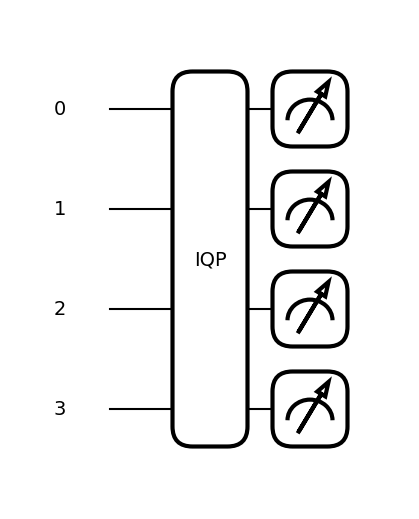

In [ ]:
# create a "lightning.qubit" device
dev = qp.device("lightning.qubit", wires=n_qubits)

@qp.qnode(dev)
def iqp_exact(weights, pattern):
  # use the IQP template
  # qp.IQP(weights, num_wires=n_qubits, pattern=pattern)
    qp.IQP(weights, num_wires=n_qubits, pattern=pattern)
    return qp.expval(qp.Z(0) @ qp.Z(1) @ qp.I(2) @ qp.I(3))

# run your qnode with arguments: params, list(gates, values())
expval = iqp_exact(params, gates)

# print the results
print("Expectation value : ", expval)
#draw your qnode
qp.draw_mpl(iqp_exact)(params, gates);

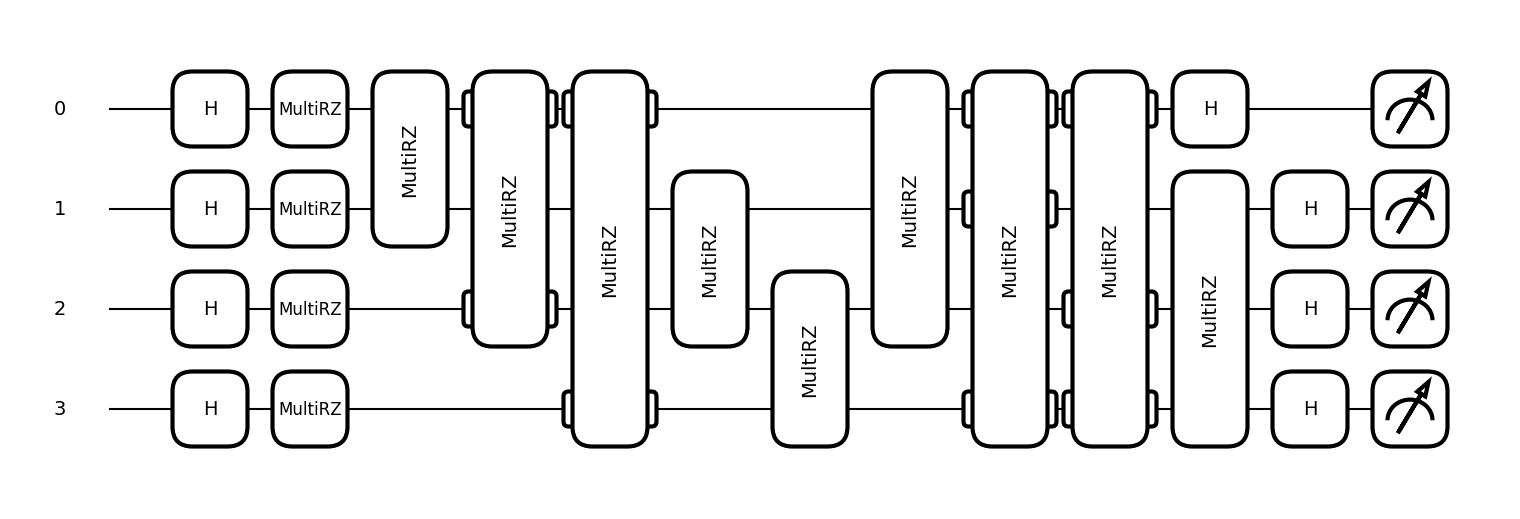

In [ ]:
# decompose the circuit into gates
# choose gate_set=qp.gate_sets.ALL_QUBIT_OPS
iqp_decomp = qp.decompose(iqp_exact, gate_set = qp.gate_sets.ALL_QUBIT_OPS)

# draw your circuit

qp.draw_mpl(iqp_decomp)(params, gates);

In [ ]:
# sample from your circuit

# set the number of shots (10)

@qp.set_shots(10)
@qp.qnode(dev)
def iqp_sample(weights, pattern):
  # use the IQP template
  # qp.IQP(weights, num_wires=n_qubit, pattern=pattern)
  qp.IQP(weights, num_wires=n_qubits, pattern=pattern)

  # return the expectation value of ZZII
  return qp.sample(qp.Z(0) @qp.Z(1) @qp.I(2) @qp.I(3))

# run your qnode with arguments: params, list(gates, values())
samples = iqp_sample(params, gates)

# print the results
print("Samples : ", samples)

Samples :  [ 1. -1. -1.  1.  1. -1. -1.  1. -1. -1.]


### Classical training

So far we used random parameters for the gates, but we can train them clasically to minimize a loss function of our choice.

In [ ]:
# choose a random ser of parameters for your gates

params = jax.random.uniform(key, shape = (len(gates),))

# define the number of Monte Carlo samples for the estimation of the expectation value.

def expval_fn(params):
  expvals, stderr = qp.qnn.iqp_expval(observables, params, gates, n_qubits, n_samples, key)
  return expvals, stderr

# Let's use 4000 samples

n_samples = 4000

# execute the expectation value computation (and standard erroes for the estimates)

expvals, std_err = expval_fn(params)

# print the results

print("Expectation values : ", expvals)
print("Standard errors : ", std_err)

Expectation values :  [0.14575177 0.243485   0.08309853 0.11885274 0.16095246 0.31090438]
Standard errors :  [0.0125994  0.01127419 0.01196597 0.01128101 0.01112519 0.00972793]


In [16]:
# definea loss function
def loss_fn(current_params):
  expvals, _ = expval_fn(current_params)

  # loss value
  loss_val = jnp.sum(expvals)

  return loss_val

# train

# define the optimizer we want to work with
opt = optax.adam(learning_rate=0.3)

# define the update step
@jax.jit
def update_step_jit(i, args):
  params, opt_state = args

  # find the new parameters based on th previous loss and gradients

  loss_val, grads = jax.value_and_grad(loss_fn)(params)
  updates, opt_state = opt.update(grads, opt_state)
  params = optax.apply_updates(params, updates)

  return params, opt_state

# define your higher-level optimizer loop
@jax.jit
def optimization_jit(params):

  opt_state = opt.init(params)
  args = (params, opt_state)
  (params, opt_state) = jax.lax.fori_loop(0, 100, update_step_jit, args)

  return params

# run the optimizer!
final_params = optimization_jit(params)

print("-------------------------")
print("Final parameters : ", final_params)
print("-------------------------")

# calculate the expectation values with the optimized parameters

expvals, std_err = expval_fn(final_params)

# print the results
expvals, std_err = expval_fn(final_params)
print("Expectation values : ", expvals)


-------------------------
Final parameters :  [ 0.7832506   0.7858334   1.5704235   0.7867236   1.519436   -0.91232646
 -0.00176099  0.7824846   0.6821546   1.5712619   0.7872      1.571994
  1.5709633 ]
-------------------------
Expectation values :  [-0.96792734 -0.97284895  0.9399925   0.9399986  -0.9729185  -0.9679946 ]


### Resourace Estimation

In [ ]:
import pennylane as qp
import pennylane.estimator as qre

# Assuming 'params' and 'gates' are available from previous cells
iqp = qp.IQP(weights=params, num_wires=n_qubits, pattern=gates)
print(qre.estimate(iqp))

--- Resources: ---
 Total wires: 4
   algorithmic wires: 4
   allocated wires: 0
     zero state: 0
     any state: 0
 Total gates : 606
   'T': 572,
   'CNOT': 26,
   'Hadamard': 8
